In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# 1. Load Dataset 

In [2]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# 2. Clean Text

In [3]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

train['comment'] = train['comment'].apply(clean_text)
test['comment'] = test['comment'].apply(clean_text)

### Exploratory Data Analysis

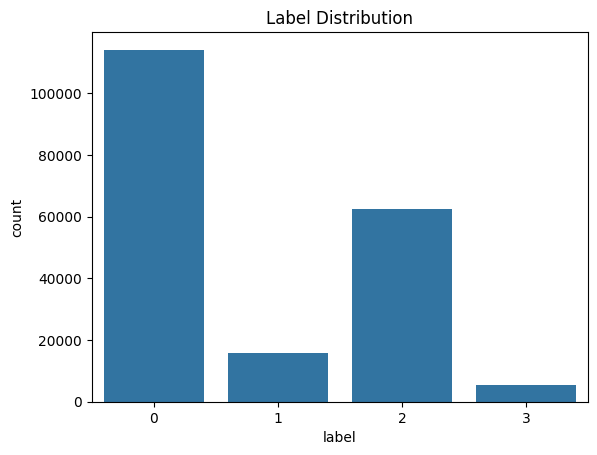

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label distribution
sns.countplot(x=train['label'])
plt.title("Label Distribution")
plt.show()

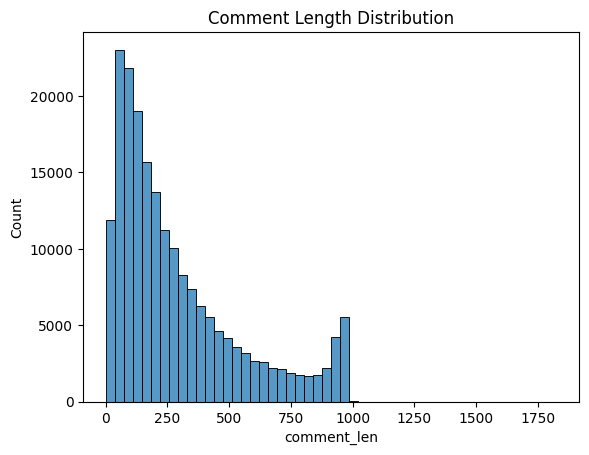

In [5]:
# Comment length
train['comment_len'] = train['comment'].apply(len)

sns.histplot(train['comment_len'], bins=50)
plt.title("Comment Length Distribution")
plt.show()

# 3. Date Features

In [6]:
train['created_date'] = pd.to_datetime(train['created_date'])
test['created_date'] = pd.to_datetime(test['created_date'])

for df in [train, test]:
    df['hour'] = df['created_date'].dt.hour
    df['dayofweek'] = df['created_date'].dt.dayofweek 

# Feature Engineering

In [7]:
for df in [train, test]:
    df['comment_len'] = df['comment'].apply(len)
    df['word_count'] = df['comment'].apply(lambda x: len(x.split()))
    df['ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['engagement'] = df['upvote'] + df['downvote']

# 5. TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    stop_words='english'
)

X_text = tfidf.fit_transform(train['comment'])
test_text = tfidf.transform(test['comment'])

# 6. Other Features

# 7. ENCODING

In [9]:
# Only run this if columns exist
for col in ['race', 'religion', 'gender']:
    if col in train.columns:
        train = pd.get_dummies(train, columns=[col])
        test = pd.get_dummies(test, columns=[col])

In [10]:
train, test = train.align(test, join='left', axis=1, fill_value=0)

# 8. FEATURES

In [11]:
features = [col for col in train.columns if col not in ['comment', 'label', 'created_date']]

In [12]:
X_other = train[features].fillna(0)
test_other = test[features].fillna(0)

In [13]:
X_other = X_other.astype(float)
test_other = test_other.astype(float)

# 9. COMBINE

In [14]:
from scipy.sparse import hstack

X_final = hstack([X_text, X_other])
test_final = hstack([test_text, test_other])

# 10. TARGET

In [15]:
y = train['label']

# 11. MODELS

# Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, solver='saga')
lr.fit(X_final, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, solver='saga')

# LightGBM

In [17]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.07,
    num_leaves=31,
    n_jobs=-1
)

model.fit(X_final, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 13.281036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 847508
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 10034
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171


LGBMClassifier(learning_rate=0.07, n_estimators=300, n_jobs=-1)

# Naive Bayes

In [18]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_final, y)

MultinomialNB()

# 12. MODEL COMPARISON

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# Logistic
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)

# LightGBM
model.fit(X_train, y_train)
pred_lgb = model.predict(X_val)

# Naive Bayes
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_val)

print("LR:", accuracy_score(y_val, pred_lr))
print("LGBM:", accuracy_score(y_val, pred_lgb))
print("NB:", accuracy_score(y_val, pred_nb))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 11.380019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 728468
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 10034
[LightGBM] [Info] Start training from score -0.547267
[LightGBM] [Info] Start training from score -2.523600
[LightGBM] [Info] Start training from score -1.159078
[LightGBM] [Info] Start training from score -3.592651


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LR: 0.7828030303030303
LGBM: 0.911010101010101
NB: 0.4068686868686869


# 13. FINAL PREDICTION

In [20]:
final_pred = model.predict(test_final)   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


# 14: SUBMISSION

In [21]:
sample['label'] = final_pred
sample.to_csv("submission.csv", index=False)